In [2]:
import numpy as np
import pandas as pd

In [3]:
!pip install requests

**1) Importing the Dataset**

In [4]:
import pandas as pd
import requests
from io import StringIO   # import these packages

url = "https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/cid/2244,1983,702,6322,5957/property/MolecularWeight,XLogP,InChIKey,CanonicalSMILES/CSV"

try:
    # Fetch the data with a timeout
    response = requests.get(url, timeout=10)

    # Check if the request was successful
    if response.status_code == 200:
        data = StringIO(response.text)
        df = pd.read_csv(data)
        print("Dataset loaded successfully!")
        print("First 5 Rows:\n", df.head())
    else:
        print(f"Failed to fetch data. Status code: {response.status_code}")
        print(f"Response text: {response.text}")
        raise Exception("Switching to fallback dataset")

except requests.exceptions.RequestException as e:
    print(f"An error occurred: {e}")
    print("Switching to fallback dataset...")

Dataset loaded successfully!
First 5 Rows:
     CID  MolecularWeight  XLogP                     InChIKey  \
0  2244           180.16    1.2  BSYNRYMUTXBXSQ-UHFFFAOYSA-N   
1  1983           151.16    0.5  RZVAJINKPMORJF-UHFFFAOYSA-N   
2   702            46.07   -0.1  LFQSCWFLJHTTHZ-UHFFFAOYSA-N   
3  6322           174.20   -4.2  ODKSFYDXXFIFQN-BYPYZUCNSA-N   
4  5957           507.18   -5.7  ZKHQWZAMYRWXGA-KQYNXXCUSA-N   

                                     CanonicalSMILES  
0                           CC(=O)OC1=CC=CC=C1C(=O)O  
1                              CC(=O)NC1=CC=C(C=C1)O  
2                                                CCO  
3                             C(CC(C(=O)O)N)CN=C(N)N  
4  C1=NC(=C2C(=N1)N(C=N2)C3C(C(C(O3)COP(=O)(O)OP(...  


In [5]:
df.head()

,CID,MolecularWeight,XLogP,InChIKey,CanonicalSMILES
0,2244,180.16,1.2,BSYNRYMUTXBXSQ-UHFFFAOYSA-N,CC(=O)OC1=CC=CC=C1C(=O)O
1,1983,151.16,0.5,RZVAJINKPMORJF-UHFFFAOYSA-N,CC(=O)NC1=CC=C(C=C1)O
2,702,46.07,-0.1,LFQSCWFLJHTTHZ-UHFFFAOYSA-N,CCO
3,6322,174.20,-4.2,ODKSFYDXXFIFQN-BYPYZUCNSA-N,C(CC(C(=O)O)N)CN=C(N)N
4,5957,507.18,-5.7,ZKHQWZAMYRWXGA-KQYNXXCUSA-N,C1=NC(=C2C(=N1)N(C=N2)C3C(C(C(O3)COP(=O)(O)OP(...


**2) Information of Dataset**

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CID              5 non-null      int64  
 1   MolecularWeight  5 non-null      float64
 2   XLogP            5 non-null      float64
 3   InChIKey         5 non-null      object 
 4   CanonicalSMILES  5 non-null      object 
dtypes: float64(2), int64(1), object(2)
memory usage: 332.0+ bytes


**Checking for NULL Values**

In [7]:
df.isnull().sum()

,0
CID,0
MolecularWeight,0
XLogP,0
InChIKey,0
CanonicalSMILES,0


**3) Data is already cleaned**

**4 and 5) Plots for visualization and Comparision**

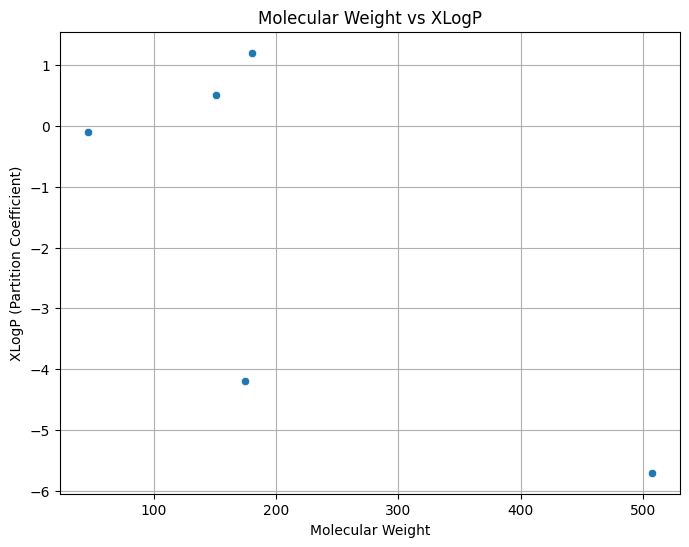

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='MolecularWeight', y='XLogP')
plt.title('Molecular Weight vs XLogP')
plt.xlabel('Molecular Weight')
plt.ylabel('XLogP (Partition Coefficient)')
plt.grid(True)
plt.show()


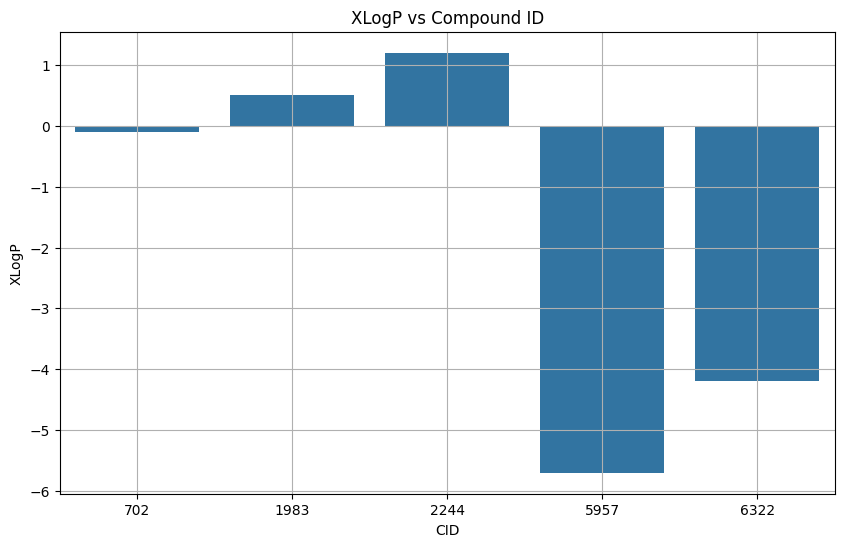

In [9]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='CID', y='XLogP')
plt.title('XLogP vs Compound ID')
plt.xlabel('CID')
plt.ylabel('XLogP')
plt.grid(True)
plt.show()

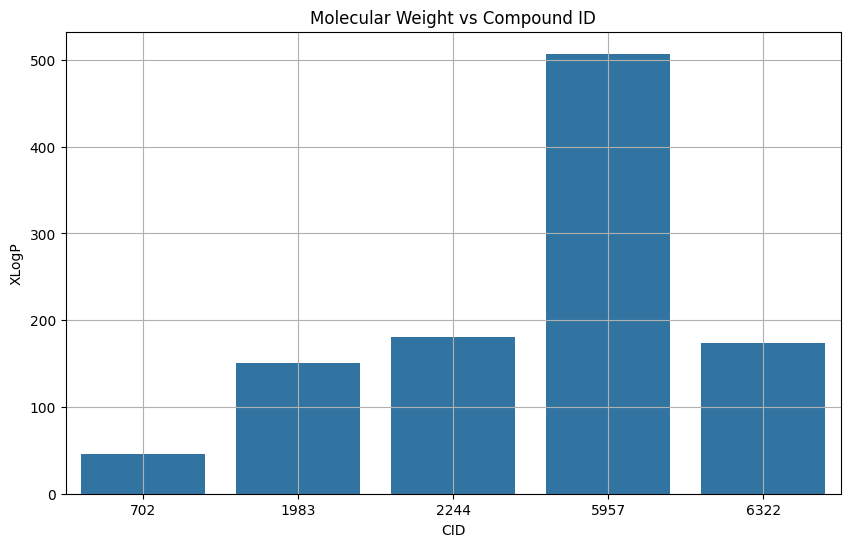

In [10]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='CID', y='MolecularWeight')
plt.title('Molecular Weight vs Compound ID')
plt.xlabel('CID')
plt.ylabel('XLogP')
plt.grid(True)
plt.show()

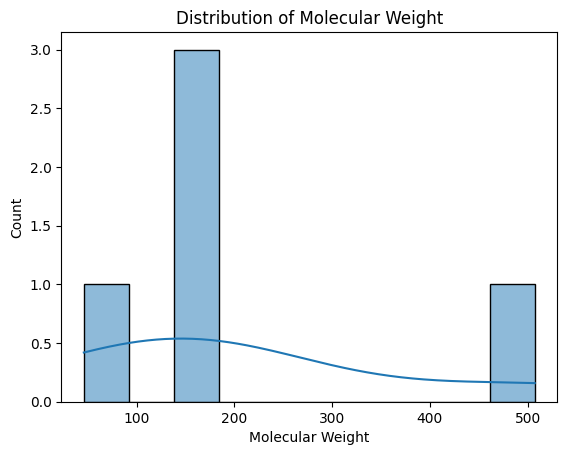

In [11]:
sns.histplot(df['MolecularWeight'], bins=10, kde=True)
plt.title('Distribution of Molecular Weight')
plt.xlabel('Molecular Weight')
plt.show()


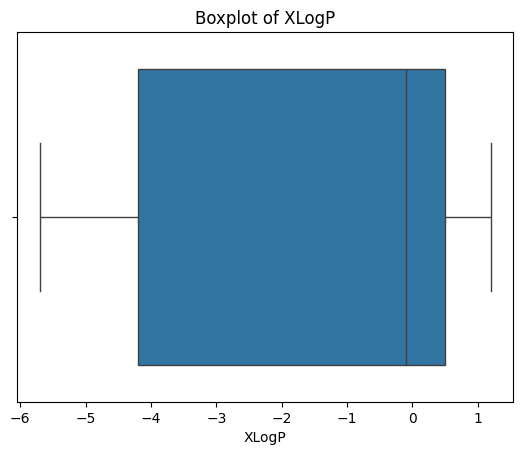

In [12]:
sns.boxplot(x='XLogP', data=df)
plt.title('Boxplot of XLogP')
plt.xlabel('XLogP')
plt.show()


**6)** Molecular Weight and XLogP are key characteristics in drug development that affect the solubility, absorption, and bioavailability. Lower MW drugs have better membrane permeability and are, therefore, more effective as oral drugs. XLogP indicates lipophilicity and an optimal value is necessary – high LogP molecules are permeable, but not soluble, whereas low LogP molecules are water soluble, but generally, less permeable. This determines the choice of the solvent: polar solvents are used for hydrophilic molecules and non-polar for lipophilic molecules. Finally, the choice of compounds with the same MW and the same LogP contributes to the optimization of the chemical and the biological activity of drug candidates.